TODO: 1. Check if it agrees with SM when dissipator is set to 0.
2. Check with Anirudh.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nudice.functions import (
    MeV,
    km,
    Uall,
    dagger,
    dynam,
    lind,
    kraus,
    mass_to_flav,
    calc_bin_centres,
)

In [2]:
e_edges = np.linspace(0.5, 5.0, 61) * MeV * 1000
e_centers = calc_bin_centres(e_edges)
n_bins = len(e_centers)

m1 = 0.0
m2 = np.sqrt(7.42e-5)
m3 = np.sqrt(2.517e-3)
masses = np.array([m1, m2, m3])
Ndim = len(masses)

theta12 = np.deg2rad(33.44)
theta23 = np.deg2rad(49.2)
theta13 = np.deg2rad(8.57)
deltaCP = np.deg2rad(195.0)
U = Uall(theta12, theta23, theta13, deltaCP)

baseline = 295.0 * km

In [3]:
# Pure nu_mu state in flavor basis.
nu_mu = np.array([0.0, 1.0, 0.0], dtype=complex)
rho_flav_0 = np.outer(nu_mu, nu_mu.conj())

rho_mass_0_single = dagger(U) @ rho_flav_0 @ U

rho0 = np.broadcast_to(rho_mass_0_single, (n_bins, Ndim, Ndim)).copy()

1. A diagonal dephasing operator, which suppresses coherences between mass eigenstates.
2. A relaxation-like jump operator from mass state 3 to mass state 1.

In [4]:
gamma_dephase = 2.0e-23
L_dephase = np.sqrt(gamma_dephase) * np.diag([0.0, 1.0, -1.0])
gamma_jump = 5.0e-24
L_jump = np.zeros((Ndim, Ndim), dtype=complex)
L_jump[0, 2] = np.sqrt(gamma_jump)

operators = np.stack([L_dephase, L_jump])

In [5]:
rho_mass_L = dynam(
    initial_value=rho0,
    L=baseline,
    e_edges=e_edges,
    masses=masses,
    operators=operators,
)

# Convert every final mass-basis density matrix back to flavor basis.
rho_flav_L = np.array([mass_to_flav(rho, U) for rho in rho_mass_L])
prob_flav = np.real(np.diagonal(rho_flav_L, axis1=1, axis2=2))
prob_flav[:3]

array([[0.04774178, 0.03282247, 0.91943576],
       [0.0464697 , 0.01980795, 0.93372235],
       [0.04311471, 0.06850466, 0.88838063]])

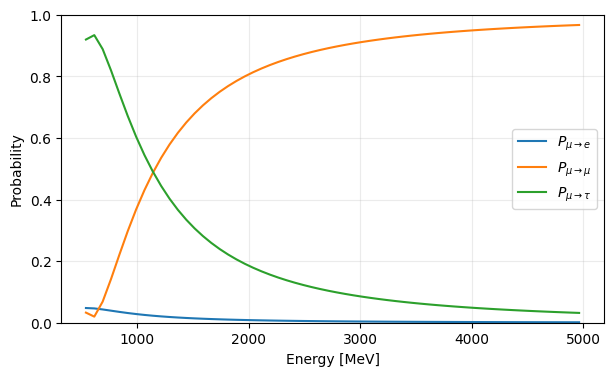

In [6]:
labels = [r"$P_{\mu\to e}$", r"$P_{\mu\to\mu}$", r"$P_{\mu\to\tau}$"]

fig, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate(labels):
    ax.plot(e_centers / MeV, prob_flav[:, i], label=label)

ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

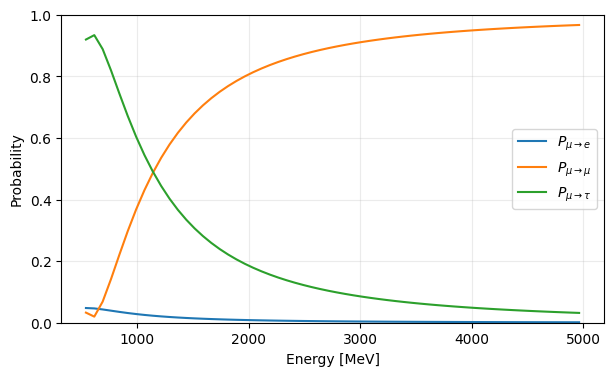

In [7]:
# SM test
rho_mass_L = dynam(
    initial_value=rho0,
    L=baseline,
    e_edges=e_edges,
    masses=masses,
)

# Convert every final mass-basis density matrix back to flavor basis.
rho_flav_L = np.array([mass_to_flav(rho, U) for rho in rho_mass_L])
prob_flav = np.real(np.diagonal(rho_flav_L, axis1=1, axis2=2))
prob_flav[:3]

labels = [r"$P_{\mu\to e}$", r"$P_{\mu\to\mu}$", r"$P_{\mu\to\tau}$"]

fig, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate(labels):
    ax.plot(e_centers / MeV, prob_flav[:, i], label=label)

ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

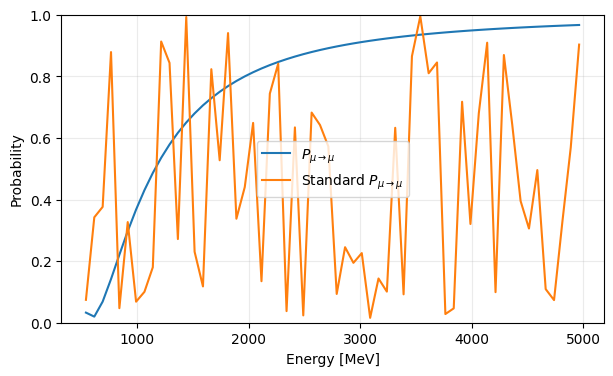

In [9]:
# compare to standard oscillation formula
import numpy as np
from scipy.linalg import expm


def pmumu_matter_full(
    L_km,
    E_GeV,
    rho=2.8,
    Ye=0.5,
    theta12=np.deg2rad(33.44),
    theta13=np.deg2rad(8.57),
    theta23=np.deg2rad(49.2),
    delta_cp=np.deg2rad(195.0),
    dm21=7.42e-5,
    dm31=2.517e-3,
    antineutrino=False,
    baseline_type = 'km'
):
    """
    Full 3-flavor nu_mu survival probability in constant-density matter.

    Parameters
    ----------
    L_km : float
        Baseline in km.
    E_GeV : float
        Neutrino energy in GeV.
    rho : float
        Matter density in g/cm^3.
    Ye : float
        Electron fraction.
    theta12, theta13, theta23 : float
        Mixing angles in radians.
    delta_cp : float
        CP phase in radians.
    dm21, dm31 : float
        Mass-squared splittings in eV^2.
        Use dm31 > 0 for normal ordering, dm31 < 0 for inverted ordering.
    antineutrino : bool
        If True, use anti-neutrino Hamiltonian:
        U -> U* and matter potential a -> -a.

    Returns
    -------
    float
        P(nu_mu -> nu_mu)
    """

    if baseline_type == 'cos':
        # Convert cos(theta) to baseline in km
        L_km = baseline(L_km)
    elif baseline_type == 'km':
        pass  # L_km is already in km
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")

    # PMNS matrix
    c12, s12 = np.cos(theta12), np.sin(theta12)
    c13, s13 = np.cos(theta13), np.sin(theta13)
    c23, s23 = np.cos(theta23), np.sin(theta23)

    U = np.array([
        [c12 * c13,
         s12 * c13,
         s13 * np.exp(-1j * delta_cp)],

        [-s12 * c23 - c12 * s23 * s13 * np.exp(1j * delta_cp),
         c12 * c23 - s12 * s23 * s13 * np.exp(1j * delta_cp),
         s23 * c13],

        [s12 * s23 - c12 * c23 * s13 * np.exp(1j * delta_cp),
         -c12 * s23 - s12 * c23 * s13 * np.exp(1j * delta_cp),
         c23 * c13]
    ], dtype=complex)

    if antineutrino:
        U = np.conjugate(U)

    # Vacuum mass-squared matrix (m1^2 set to 0)
    M2_vac = np.diag([0.0, dm21, dm31])

    # Matter potential in eV^2
    # a = 2*sqrt(2)*GF*Ne*E ≈ 2 * 7.63247e-5 * rho[g/cm^3] * Ye * E[GeV]
    a = 2 * 7.63247e-5 * rho * Ye * E_GeV
    if antineutrino:
        a = -a

    V = np.diag([a, 0.0, 0.0])

    # Effective mass-squared matrix in flavor basis
    M2_flavor = U @ M2_vac @ U.conj().T + V

    # Hamiltonian in 1/km units:
    # H = (1 / (2E)) M2, with the usual conversion factor 1.267
    H = 2 * 1.267 * M2_flavor / E_GeV

    # Evolution operator: exp[-i H L]
    S = expm(-1j * H * L_km)

    # nu_mu is index 1
    amp = S[1, 1]
    prob = np.abs(amp) ** 2

    # Remove tiny numerical drift outside [0,1]
    return float(np.clip(prob.real, 0.0, 1.0))

# print(pmumu_matter_full(L_km = 1, E_GeV = 1, rho = 0))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e_centers / MeV, prob_flav[:, 1], label=r"$P_{\mu\to\mu}$")
ax.plot(e_centers / MeV, [pmumu_matter_full(L_km = baseline, E_GeV = i, rho = 0) for i in e_centers /(1000* MeV)], label=r"Standard $P_{\mu\to\mu}$")

ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

pmue matter effect
check with nudice
entropy, off diagnol